# imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC# SVM(Support Vector Machine) 알고리즘을 사용한 분류기
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
                                              # 중복허용 샘플링
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
                                                          # 부스팅 활용
from sklearn.model_selection import GridSearchCV #교차검증

# Ensemble Learning(앙상블 학습 방법)

* 앙상블(ensemble): ML에서 사용되는 일련의 모델(알고리즘)들.
  * 서로 다른 모델(알고리즘,**분류끼리 회귀끼리**) 여러개를 훈련시키는 방법.
  * 한 가지 모델(알고리즘)을 서로 다른 훈련 셋으로 훈련시키는 방법.
* 앙상블 학습방법: 앙상블을 사용한 학습 방법
  * 투표(voting): 여러 개의 모델들을 같은 훈련 셋으로 학습시킨 후, 각각의 모델들의 예측값들을 투표(분류- 최빈값(다수결), 회귀- 평균) 방식으로 결정하는 방법.
  * **Bagging(Bootstrap Aggregating)**: **중복을 허용**해서 샘플링한 훈련 셋의 부분집합들로 여러개의 모델들을 학습시킨 후 예측(분류- 최빈값(다수결), 회귀- 평균)하는 방법.
  * Pasting: 중복을 허용하지 않고 샘플링한 훈련 셋의 부분집합들로 여러 개의 모델들을 학습시킨후에 예측하는 방법.
  * **Boosting**: 약한 학습기(weak learner)를 **순차적**으로 연결해서 강한 학습기(strong learner)를 만드는 앙상블 학습 방법.
  * AdaBoost(Adaptive Boosting): 과속적합됐던 훈련 샘플들의 가중치를 높여서 그 다음 학습에서 사용하는 boosting 방법.
  * Gradient Boosting: 잔여 오차(residual errors)들을 다음 훈련에서 학습시키는 boosting 방법.
* **Random Forest**: Bagging을 이용한 Decision Tree들의 앙상블 학습 방법. (프로젝트)

# 데이터셋 준비

2개의 특성(x1, x2)과 2개의 클래스(0, 1)를 갖는 가상의 데이터셋을 만들고 사용.

In [2]:

# load, fetch 실제 데이터프레임
# make 난수 데이터프레임
# x: 특성 배열
# y: 타겟 배열
x, y = datasets.make_moons(n_samples=500, random_state=42, noise=0.3)# 노이즈가 작아지면 점이 얉쌍해진다

In [3]:
x.shape, y.shape

((500, 2), (500,))

In [4]:
np.unique(y, return_counts=True)

(array([0, 1]), array([250, 250]))

In [5]:
x[:6]
# x1,      x2,    y(class)

array([[ 0.83103915, -0.25874875],
       [ 1.18506381,  0.92038714],
       [ 1.16402213, -0.45552558],
       [-0.0236556 ,  1.08628844],
       [ 0.48050273,  1.50942444],
       [ 1.31164912, -0.55117606]])

In [6]:
y[:6]
# class

array([1, 0, 1, 0, 0, 1])

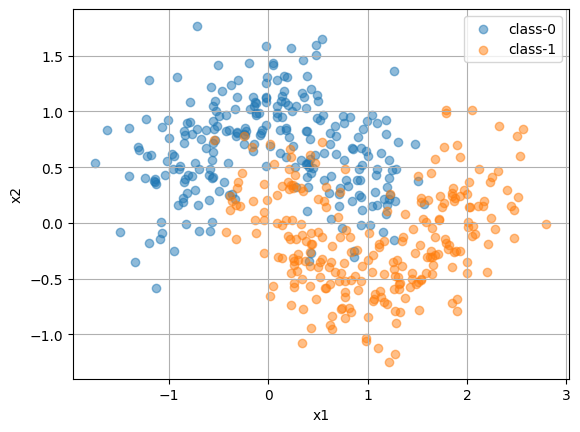

In [7]:
plt.scatter(x[y==0,0],x[y==0,1],label='class-0',alpha=0.5)
              #x1,         x2
plt.scatter(x[y==1,0],x[y==1,1],label='class-1',alpha=0.5)

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()

# 머신 러닝 모델의 성능 비교

*   5개의 ML 모델 생성
    *   KNN, Decision Tree, Logistic Regression, SGD, SVM 기본 생성자
        *   SGDClassifier의 파라미터 중에서 loss='log_loss' 사용.# 확률계산후 예측
        *   SVC의 파라미터 중에서 probability=True 사용.# 확률계산후 예측
*   5개의 모델을 각각 훈련 셋으로 학습시킴
*   5개 모델의 점수(score -> 정확도)를 훈련/테스트 셋에서 계산, 출력.


In [8]:
# 훈련 셋, 테스트 셋 나누기
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)


In [9]:
x_train.shape

(400, 2)

In [10]:
# 성능을 비교하기 위한 예측기(estimator)
knn=KNeighborsClassifier(n_jobs=-1)
detree=DecisionTreeClassifier(random_state=42)
logi=LogisticRegression(random_state=42, n_jobs=-1)
sgd=SGDClassifier(loss='log_loss',random_state=42,n_jobs=-1)
svm=SVC(probability=True,random_state=42)# 확률계산후 예측
#False hinge soft조합해보기 =
#AttributeError: This 'SGDClassifier' has no attribute 'predict_proba'


In [11]:
knn.fit(x_train,y_train)

KNeighborsClassifier(n_jobs=-1)

In [12]:
knn.score(x_train,y_train)


0.93

In [13]:
knn.score(x_test,y_test)

0.93

In [14]:
detree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
detree.score(x_train,y_train)

1.0

In [16]:
detree.score(x_test,y_test)

0.84

In [17]:
logi.fit(x_train,y_train)

LogisticRegression(n_jobs=-1, random_state=42)

In [18]:
logi.score(x_train,y_train)

0.8475

In [19]:
logi.score(x_test,y_test)

0.81

In [20]:
sgd.fit(x_train,y_train)

SGDClassifier(loss='log_loss', n_jobs=-1, random_state=42)

In [21]:
sgd.score(x_train,y_train)

0.8425

In [22]:
sgd.score(x_test,y_test)

0.81

In [23]:
svm.fit(x_train,y_train)

SVC(probability=True, random_state=42)

In [24]:
svm.score(x_train,y_train)

0.9275

In [25]:
svm.score(x_test,y_test)

0.93

In [26]:
estimators = [knn,detree,logi,sgd,svm]
for e in estimators:
  e.fit(x_train,y_train)
  trainscore=e.score(x_train,y_train) # 분류 - 정확도
  testscore=e.score(x_test,y_test) # 정확도
  print(f'{e.__class__.__name__}: train score={trainscore},test score={testscore}') # 클래스 풀네임출력

KNeighborsClassifier: train score=0.93,test score=0.93
DecisionTreeClassifier: train score=1.0,test score=0.84
LogisticRegression: train score=0.8475,test score=0.81
SGDClassifier: train score=0.8425,test score=0.81
SVC: train score=0.9275,test score=0.93


# Voting Ensemble

In [27]:
# VotingClassifier 객체 생성
voting_clf=VotingClassifier(estimators=[('knn',knn),('detree',detree),('logistic',logi),('sgdc',sgd),('svc',svm)],
                            voting='soft', n_jobs=-1)

Voting Classifier 생성자 파라미터:

* estimator: 앙상블을 만들기 위한 예측기(ML 모델)들의 리스트.
  * ('str',estimator)형식의 튜플들을 리스트의 아이템으로 설정.
* voting: 투표 방식
  * voting='hard': 기본값. 단순한 다수결로 예측. 각각의 예측기에서 예측 확률을 계산할 필요가 없음.
  * voting='soft': 각각의 예측기에서 계산한 예측 확률을 가중치로 곱한 값을 사용해서 최종 결과를 도출.
  * 일반적으로 soft voting 방식이 성능이 더 좋다고 알려져 있음.

In [28]:
# VotingClassifier 훈련
voting_clf.fit(x_train,y_train)

VotingClassifier(estimators=[('knn', KNeighborsClassifier(n_jobs=-1)),
                             ('detree',
                              DecisionTreeClassifier(random_state=42)),
                             ('logistic',
                              LogisticRegression(n_jobs=-1, random_state=42)),
                             ('sgdc',
                              SGDClassifier(loss='log_loss', n_jobs=-1,
                                            random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [29]:
print('trainscore=',voting_clf.score(x_train,y_train))
print('testscore=',voting_clf.score(x_test,y_test))

trainscore= 0.94
testscore= 0.92


# Bagging Ensemble

In [30]:
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                n_estimators=50,
                                oob_score=True,
                                bootstrap=True,
                                n_jobs=-1,random_state=42)

BaggingClassifier 생성자 파라미터:
* estimator: 앙상블을 만들기 위한 예측기.
* n_estimators: 예측기 개수. 기본값 10.
* max_samples: 훈련 셋에서 랜덤 샘플링한 부분 집합이 가질 수 있는 최대 샘플 개수(정수) 또는 비율(0.0 ~ 1.0). 기본값 1.0
* bootstrap: 중복 허용 샘플링 여부.
  * bootstrap=True: 중복 허용. bagging(bootstrap aggregating). 기본값.
  * bootstrap=False: 중복 허용 않음. pasting.
* oob_score: OOB(Out of Bagging) 샘플들을 사용해서 검증 점수를 계산할 지 여부. 기본값은 False.
  * OOB samples: 중복 허용 샘플링을 하는 동안 한 번도 샘플링 되지 못하고 남아있는 훈련 셋 샘플. 한 번도 훈련되지 못한 훈련 샘플들.
  * OOB 샘플들은 검증 셋 역할을 할 수 있음.

In [31]:
# BaggingClassifier 훈련
bagging_clf.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, oob_score=True, random_state=42)

In [32]:
# OOB 샘플들을 사용한 검증 변수
bagging_clf.oob_score_
# 훈련끝 점수예측 완료 변수_

0.89

In [33]:
bagging_clf.score(x_train,y_train) # 훈련 셋 점수(정확도)

1.0

In [34]:
bagging_clf.score(x_test,y_test) # 테스트 셋 점수(정확도)

0.89

* estimator: Decision Tree
* n_estimators: 100
* 교차검증(cross_validate)

In [35]:
bagging_clf=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                              n_estimators=100,
                              random_state=42,
                              n_jobs=-1)

In [36]:
cv=cross_validate(estimator=bagging_clf,X=x_train,y=y_train,cv=5,n_jobs=-1,return_train_score=True)

In [37]:
cv

{'fit_time': array([0.90804505, 0.93723583, 0.79113317, 0.8356092 , 0.45242691]),
 'score_time': array([0.06044674, 0.06985211, 0.06687403, 0.07449579, 0.05387378]),
 'test_score': array([0.875 , 0.925 , 0.9375, 0.925 , 0.875 ]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [38]:
print('train score=',np.mean(cv['train_score']))
print('train score=',np.mean(cv['test_score']))

train score= 1.0
train score= 0.9075


* estimator: Decision Tree
* n_estimators: 50
* max_samples: 100
* 교차검증(cross_validate)


In [39]:
bagging_clf=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                              n_estimators=50,
                              max_samples=100,
                              random_state=42,
                              n_jobs=-1)

In [40]:
cv=cross_validate(estimator=bagging_clf,X=x_train,y=y_train,cv=5,n_jobs=-1,return_train_score=True)

In [41]:
cv

{'fit_time': array([0.41145968, 0.37422562, 0.37855577, 0.35001493, 0.23601675]),
 'score_time': array([0.04275155, 0.04619694, 0.04419398, 0.02644038, 0.02824521]),
 'test_score': array([0.875 , 0.95  , 0.9125, 0.9   , 0.925 ]),
 'train_score': array([0.95    , 0.93125 , 0.946875, 0.940625, 0.940625])}

In [42]:
print('train score=',np.mean(cv['train_score']))
print('train score=',np.mean(cv['test_score']))

train score= 0.9418749999999999
train score= 0.9125


# Random Forest



Random Forest: bagging(bootstrap aggregating)을 사용한 결정나무(Decision tree)들의 앙상블 학습 방법.

* DecisionTreeClassifier의 파라미터들을 가지고 있음.
* BaggingClassifier의 파라미터들을 가지고 있다.
* 교차검증(CV)으로 decision tree와 bagging의 하이퍼 파라미터들을 튜닝할 수 있음.

In [43]:
forest = RandomForestClassifier(n_estimators=50, max_samples=100,
                                random_state=42, n_jobs=-1)

In [44]:
cv = cross_validate(estimator=forest,X=x_train,y=y_train,cv=5,n_jobs=-1,return_train_score=True)


In [45]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 0.9493750000000001
test score: 0.9274999999999999


In [46]:
cv

{'fit_time': array([0.25268507, 0.19741011, 0.35958457, 0.31602526, 0.21595311]),
 'score_time': array([0.03232145, 0.04374099, 0.02601552, 0.02761197, 0.0417366 ]),
 'test_score': array([0.8875, 0.975 , 0.925 , 0.9125, 0.9375]),
 'train_score': array([0.953125, 0.946875, 0.94375 , 0.95    , 0.953125])}

GridSearchCV 사용한 Random Forest 하이퍼 파라미터 튜

In [47]:
forest=RandomForestClassifier(random_state=42)

In [48]:
params = {'max_depth': np.arange(2, 11),
          'min_samples_split': np.arange(2, 11, 2),
          'n_estimators': [50, 100, 200],
          'max_samples': [0.25, 0.5, 0.75, 1.0]}

In [49]:
grid=GridSearchCV(estimator=forest,param_grid=params,n_jobs=-1)

In [50]:
grid.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_samples': [0.25, 0.5, 0.75, 1.0],
                         'min_samples_split': array([ 2,  4,  6,  8, 10]),
                         'n_estimators': [50, 100, 200]})

In [51]:
grid.best_estimator_

RandomForestClassifier(max_depth=np.int64(6), max_samples=1.0,
                       min_samples_split=np.int64(2), n_estimators=200,
                       random_state=42)

In [52]:
grid.best_score_

np.float64(0.925)

In [53]:
grid.best_params_

{'max_depth': np.int64(6),
 'max_samples': 1.0,
 'min_samples_split': np.int64(2),
 'n_estimators': 200}

# Random Forest를 사용한 wine 분류

In [54]:
wine=pd.read_csv('https://bit.ly/wine_csv_data')

In [55]:
wine[:5]

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [56]:
feature_names=wine.columns[:3]

In [57]:
x=wine[feature_names].to_numpy()
y=wine['class'].to_numpy()

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [59]:
# randomforest
# cv
# gridsearch-하이퍼파라미터

In [60]:
forest=RandomForestClassifier(random_state=42,n_jobs=-1)

In [61]:
params={
    'n_estimators':[10,50,100,150],
    'max_depth':np.arange(2,11,2),
    'min_samples_split':[2,10,20,50],
    'min_impurity_decrease':[0.0,0.001,0.01,0.1],
}

In [62]:
cv=cross_validate(estimator=forest,X=x_train,y=y_train,cv=5,n_jobs=-1,return_train_score=True)

In [63]:
cv

{'fit_time': array([0.70585108, 0.6690588 , 0.66294289, 0.65894747, 0.41618061]),
 'score_time': array([0.06039882, 0.05939007, 0.04571271, 0.05826592, 0.0354774 ]),
 'test_score': array([0.90480769, 0.89903846, 0.88546679, 0.89412897, 0.88546679]),
 'train_score': array([0.99807554, 0.99807554, 0.9983165 , 0.998076  , 0.9983165 ])}

In [64]:
print('train score=',np.mean(cv['train_score']))
print('test score=',np.mean(cv['test_score']))

train score= 0.9981720130385032
test score= 0.8937817428000298


In [65]:
gridcv=GridSearchCV(forest,params,n_jobs=-1)

In [66]:
gridcv.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([ 2,  4,  6,  8, 10]),
                         'min_impurity_decrease': [0.0, 0.001, 0.01, 0.1],
                         'min_samples_split': [2, 10, 20, 50],
                         'n_estimators': [10, 50, 100, 150]})

In [67]:
gridcv.best_score_

np.float64(0.8820457910712964)

In [68]:
gridcv.best_params_

{'max_depth': np.int64(10),
 'min_impurity_decrease': 0.0,
 'min_samples_split': 2,
 'n_estimators': 100}

In [69]:
best_model = gridcv.best_estimator_
best_model.score(x_train, y_train) # grid search cv가 찾은 최적의 모델로 훈련 셋 점수 계산
# 과대적합이 줄어듬

0.9297671733692515

# Extra Tree

Extra Tree
* Random Forest와 비슷한 점:
  * 여러 개(기본값 100)의 decision tree들을 훈련시키는 앙상블 학습.
  * decision tree의 파라미터(max_depth, min_samples_split, ...)들을 튜닝할 수 있음.
* Random Forest와 다른 점:
  * bagging을 사용하지 않음.
    * 여러 개의 decision tree들을 전체 훈련 셋을 사용해서 훈련시킴.
  * 노드를 분할할 때 가장 좋은 분할 방법을 찾는 게 아니라 무작위(random)로 분할.    
    * Random Forest는 각각의 tree들이 최적의 노드 분할을 찾기 위해서 많은 훈련 시간이 필요.
    * Extra Tree는 무작위 분할을 하기 때문에 훈련 시간이 빠름.

In [70]:
extra_tree = ExtraTreesClassifier(n_jobs=-1,random_state=42)

In [71]:
cv=cross_validate(extra_tree,x_train,y_train,n_jobs=-1,return_train_score=True)

In [72]:
cv

{'fit_time': array([0.72321534, 0.71787906, 1.06349254, 1.07566428, 0.54453683]),
 'score_time': array([0.10337162, 0.08038712, 0.08827186, 0.10268736, 0.05735636]),
 'test_score': array([0.89519231, 0.90480769, 0.88450433, 0.89509143, 0.8825794 ]),
 'train_score': array([0.99807554, 0.99807554, 0.9983165 , 0.998076  , 0.9983165 ])}

In [73]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))

train score: 0.9981720130385032
test score: 0.8924350336862368


In [74]:
# gridsearch - 하이퍼 파라미터 튜닝


# Gradient Boosting

Gradient Boosting

* 깊이(depth)가 얕은 결정 나무들을 순차적으로(직렬로) 연결해서 훈련시킴.
* 훈련 과정에서, 이전 훈련 단계에서 발생한 오차들을 그 다음 훈련에서 가중치를 주고 훈련시킴.
  * 오차들을 학습하는 알고리즘.
* 장점: 깊이가 얕은 결정 나무들을 사용하기 때문에, 과대적합이 작아지고 높은 일반화 성능을 기대할 수 있음.
* 단점: Random Forest처럼 병렬로 훈련시킬 수가 없기 때문에 훈련 시간이 느림.
* SGD + Decision Tree + Ensemble 하이퍼 파라미터들을 튜닝할 수 있음.  

In [75]:
grad_boost = GradientBoostingClassifier(random_state=42) # 직렬훈련 n_jobs=-1불가능

In [76]:
cv= cross_validate(estimator=grad_boost,X=x_train,y=y_train,n_jobs=-1,return_train_score=True) # 병렬가능

In [77]:
cv

{'fit_time': array([0.61336517, 0.59851909, 0.53799605, 0.53899837, 0.4034183 ]),
 'score_time': array([0.00443649, 0.00441027, 0.00436616, 0.00454235, 0.0032053 ]),
 'test_score': array([0.87692308, 0.87692308, 0.86717998, 0.87680462, 0.85948027]),
 'train_score': array([0.88501323, 0.88645658, 0.89009139, 0.88287638, 0.88624339])}

In [78]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))
# 과대적합이 거의 없음.

train score: 0.886136193834053
test score: 0.8714622047827053


# Histogram 기반 Gradient Boosting

노드를 분할할때 최적의 노드를 빠르게 찾을 수 있음.

In [79]:
from sklearn.ensemble import HistGradientBoostingClassifier


In [80]:
hist_gb= HistGradientBoostingClassifier(random_state=42)

In [81]:
cv=cross_validate(hist_gb,x_train,y_train,n_jobs=-1,return_train_score=True)

In [82]:
cv

{'fit_time': array([0.36026096, 0.36064839, 0.34417629, 0.34782982, 0.21688962]),
 'score_time': array([0.01787996, 0.01817083, 0.01898289, 0.01836872, 0.01401353]),
 'test_score': array([0.88942308, 0.88942308, 0.86621752, 0.87872955, 0.86621752]),
 'train_score': array([0.92494587, 0.92975704, 0.93145743, 0.93145743, 0.93506494])}

In [83]:
print('train score:',np.mean(cv['train_score']))
print('test score:',np.mean(cv['test_score']))


train score: 0.930536541746549
test score: 0.8780021470348707


# XGBoost(Extreme Gradient Boosting)

In [84]:
import xgboost as xgb

from xgboost import XGBClassifier, XGBRegressor

In [85]:
gb=xgb.XGBClassifier()#learning_rate=0.1,max_depth=5,n_estimators=100,n_jobs=-1

In [86]:
# gb.fit(x_train,y_train)

In [87]:
cv=cross_validate(gb,x_train,y_train,n_jobs=-1,return_train_score=True)

In [88]:
cv

{'fit_time': array([0.14092517, 0.13938069, 0.09413981, 0.09291053, 0.07188106]),
 'score_time': array([0.00797033, 0.0089221 , 0.00771928, 0.00799513, 0.00793076]),
 'test_score': array([0.89038462, 0.89038462, 0.86910491, 0.87487969, 0.86333013]),
 'train_score': array([0.94539331, 0.95477508, 0.95622896, 0.95165945, 0.95670996])}

# Light GBM

In [89]:
import lightgbm as lgb

from lightgbm import LGBMClassifier, LGBMRegressor

In [90]:
light=lgb.LGBMClassifier(
                         )#max_depth=10,learning_rate=0.1,n_estimators=0.1,n_jobs=-1,random_state=42

In [91]:
# light.fit(x_train,y_train)

In [92]:
cv=cross_validate(light,x_train,y_train,n_jobs=-1,return_train_score=True)

In [93]:
cv

{'fit_time': array([0.16318536, 0.15386248, 0.09902239, 0.097296  , 0.07195425]),
 'score_time': array([0.0159719 , 0.01614451, 0.0135572 , 0.01466537, 0.01133657]),
 'test_score': array([0.89230769, 0.88557692, 0.87102984, 0.88642926, 0.86717998]),
 'train_score': array([0.93288429, 0.93553043, 0.93698894, 0.93241943, 0.93506494])}